# 1) Demonstrate Bayesian Strategy Analysis

This notebook shows a single-strategy Bayesian analysis step by step.

Use this workflow for your own dataset:
1. Import packages and toolbox functions
2. Load your CSV
3. Standardize column/value format
4. Validate required columns
5. Run Bayesian update across trials


You do not need to edit notebook code; set your `.csv` path in `config.py` (`data_path`) and run the cells.



In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name

TestData = pd.read_csv(data_path)

try:
    TestData = standardize_dataset(TestData)
except ValueError as e:
    msg = str(e)
    if "must contain column" in msg:
        missing = msg.split("'")[1]
        print(f"\n❌ ERROR: Your CSV is missing the required column '{missing}'.")
        print(f"   Your CSV has these columns: {list(TestData.columns)}")
        print(f"\n   Fix: In config.py, update COLUMN_MAPPING so that your column name maps to '{missing}'.")
        print(f"   Example:  COLUMN_MAPPING = {{\"your_column_name\": \"{missing}\", ...}}")
        print(f"   Then load with: standardize_dataset(TestData, column_mapping=COLUMN_MAPPING)")
    elif "Unsupported numeric encoding in 'Choice'" in msg:
        print(f"\n❌ ERROR: 'Choice' column contains unrecognised values.")
        print(f"   {msg}")
        print(f"\n   Fix: Choice must be 'left'/'right', 0/1, or 1/2.")
        print(f"   If your values are different (e.g. 'L'/'R'), manually recode them before calling standardize_dataset.")
    elif "Unsupported numeric encoding in 'CuePosition'" in msg:
        print(f"\n❌ ERROR: 'CuePosition' column contains unrecognised values.")
        print(f"   {msg}")
        print(f"\n   Fix: CuePosition must be 'left'/'right', 0/1, or 1/2.")
    elif "Unsupported numeric encoding in 'Reward'" in msg:
        print(f"\n❌ ERROR: 'Reward' column contains unrecognised values.")
        print(f"   {msg}")
        print(f"\n   Fix: Reward must be 'yes'/'no' or 0/1.")
    else:
        print(f"\n❌ ERROR during standardization:\n   {msg}")
    raise

no_Trials = len(TestData)
print(f"Dataset loaded: {no_Trials} trials")

[standardize_dataset] Removed 1 omission trial(s) from 'Choice'.
Dataset loaded: 1407 trials


## Step 1: Load and standardize your dataset

`data_path` comes from `config.py`. To analyse your own file, update only `data_path` in `config.py`.

This step:
- Loads your CSV into `TestData`
- Standardizes the key columns (`TrialIndex`, `Choice`, `CuePosition`, `Reward`)
- Checks that `TrialIndex` exists
- Shows the first rows so you can verify formatting


In [2]:
TestData = pd.read_csv(data_path)

try:
    TestData = standardize_dataset(TestData)
except ValueError as e:
    msg = str(e)
    if "must contain column" in msg:
        missing = msg.split("'")[1]
        print(f"\n❌ ERROR: Your CSV is missing the required column '{missing}'.")
        print(f"   Your CSV has these columns: {list(TestData.columns)}")
        print(f"\n   Fix: In config.py, update COLUMN_MAPPING so that your column name maps to '{missing}'.")
        print(f"   Example:  COLUMN_MAPPING = {{\"your_column_name\": \"{missing}\", ...}}")
        print(f"   Then load with: standardize_dataset(TestData, column_mapping=COLUMN_MAPPING)")
    elif "Unsupported numeric encoding in 'Choice'" in msg:
        print(f"\n❌ ERROR: 'Choice' column contains unrecognised values.")
        print(f"   {msg}")
        print(f"\n   Fix: Choice must be 'left'/'right', 0/1, or 1/2.")
        print(f"   If your values are different (e.g. 'L'/'R'), manually recode them before calling standardize_dataset.")
    elif "Unsupported numeric encoding in 'CuePosition'" in msg:
        print(f"\n❌ ERROR: 'CuePosition' column contains unrecognised values.")
        print(f"   {msg}")
        print(f"\n   Fix: CuePosition must be 'left'/'right', 0/1, or 1/2.")
    elif "Unsupported numeric encoding in 'Reward'" in msg:
        print(f"\n❌ ERROR: 'Reward' column contains unrecognised values.")
        print(f"   {msg}")
        print(f"\n   Fix: Reward must be 'yes'/'no' or 0/1.")
    else:
        print(f"\n❌ ERROR during standardization:\n   {msg}")
    raise

TestData.head()

[standardize_dataset] Removed 1 omission trial(s) from 'Choice'.


,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,Group,Overtrain,RT,RuleChangeTrials,NewSessionTrials,StartDate
0,1,1,go right,left,left,no,notOT,no,0.8,0,0,06-Mar-2023
1,2,1,go right,right,right,yes,notOT,no,0.4,0,0,06-Mar-2023
2,3,1,go right,left,left,no,notOT,no,0.4,0,0,06-Mar-2023
3,4,1,go right,left,right,no,notOT,no,0.4,0,0,06-Mar-2023
4,5,1,go right,left,left,no,notOT,no,0.4,0,0,06-Mar-2023


In [3]:
available_strategies = [
    s for s in dir(strategymodels)
    if callable(getattr(strategymodels, s)) and not s.startswith("_")
]

try:
    strategy_fcn = getattr(strategymodels, strategy_name)
except AttributeError:
    raise ValueError(
        f"Strategy '{strategy_name}' not found.\nAvailable strategies:\n{available_strategies}"
    )

## Step 3: Initialize priors and output storage

In [4]:
alpha0, beta0 = set_priors(prior_type)
no_Trials = len(TestData)

success_total = 0
failure_total = 0

Output = pd.DataFrame(columns=["Alpha", "Beta", "MAPprobability", "Precision"])

## Step 4: Run Bayesian updates trial by trial

In [5]:
for trial in range(len(TestData)):
    rows_of_data = TestData.iloc[0:trial+1]

    trial_type = strategy_fcn(rows_of_data)

    success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
        trial_type,
        decay_rate,
        success_total,
        failure_total,
        alpha0,
        beta0,
    )

    MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
    precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

    new_row = {
        "Alpha": Alpha,
        "Beta": Beta,
        "MAPprobability": MAPprobability,
        "Precision": precision,
    }

    Output = pd.concat([Output, pd.DataFrame([new_row])], ignore_index=True)

if save_output_csv:
    Output.to_csv("Output.csv", index=False)

## Step 5: Plot MAP probability across trials

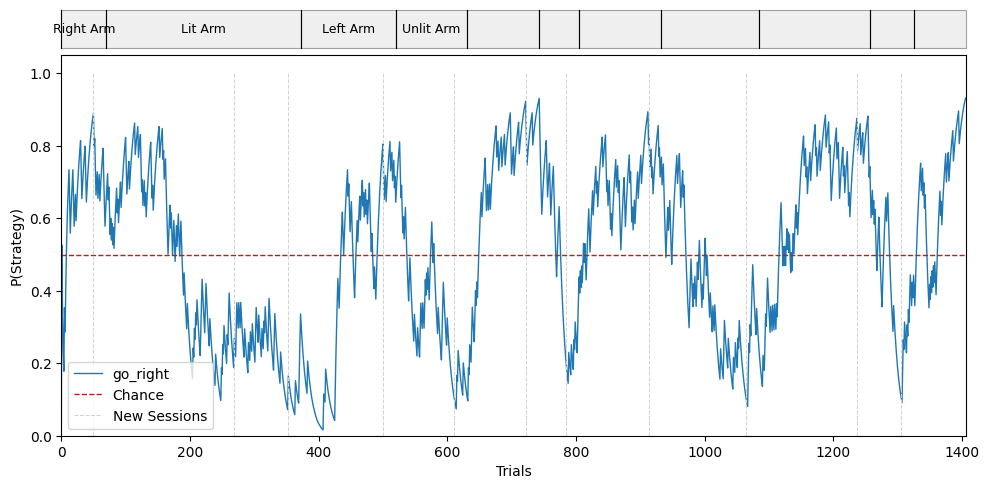

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(Output["MAPprobability"], linewidth=1.0, label=strategy_name)

plt.xlabel("Trials")
plt.ylabel("P(Strategy)")

plt.axhline(
    y=0.5,
    color="firebrick",
    linestyle="--",
    linewidth=1.0,
    label="Chance",
)

try:
    plotSessionStructure(TestData)
except Exception:
    pass

plt.axis([0, no_Trials, 0, 1.05])
plt.legend()
plt.tight_layout()
plt.show()

---
## Next Step

To analyse multiple strategies and reproduce Figure 1, run:

**2_Replicate_Figure1.ipynb**
